# Sound 04: Divergence Anatomy

**Question:** What is driving the liberal-conservative network divergence? Which edges, domains, and structural properties are changing?

Sound 03 established that lib/con belief networks have been diverging for 48 years
(1974-2022), with Euclidean distance rising from 0.72 to 1.29 (slope=+0.010/yr, r=0.852, p<0.0001).
This notebook dissects *what* is diverging.

**Sections:**
- 4.1 Edge sign disagreements (same direction vs opposite direction?)
- 4.2 Dimensionality divergence (structural complexity changing differently?)
- 4.3 Edge-level divergence drivers (which specific edges?)
- 4.4 Domain decomposition (which belief domains?)
- 4.5 Modularity divergence (belief packaging changing differently?)
- 4.6 Centrality divergence (disagreeing on which beliefs are central?)

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from tqdm.auto import tqdm
from scipy.stats import linregress, spearmanr

from src.loaders.clean_raw_data import clean_datasets
from src.generators.corr_make_network import (
    calculate_correlation_matrix, CorrelationMethod, EdgeSuppressionMethod
)

C:\Users\timbo\miniconda3\Lib\site-packages\outdated\utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.0.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [2]:
cleaned_df = clean_datasets()

METHOD = CorrelationMethod.PEARSON
EDGE_SUPP = EdgeSuppressionMethod.REGULARIZATION
SUPP_PARAMS = {'regularization': 0.2}

WINDOW_SIZE = 4
STEP_SIZE = 2

polviews_years = sorted(cleaned_df[cleaned_df['POLVIEWS'].notna()]['YEAR'].unique())
polviews_years = [int(y) for y in polviews_years]

first_year = int(polviews_years[0])
last_year = int(polviews_years[-1])
window_starts = list(range(first_year, last_year - WINDOW_SIZE + 2, STEP_SIZE))
print(f"POLVIEWS years: {polviews_years[0]}-{polviews_years[-1]}")
print(f"Rolling windows: {len(window_starts)} windows, {first_year}-{window_starts[-1]+WINDOW_SIZE}")

Loading dataset from from cache...


Done! ✨


POLVIEWS years: 1974-2022
Rolling windows: 23 windows, 1974-2022


## 4.0 Data Collection

Same rolling-window loop as sound_03, but we store the **full correlation matrices**
per window (not just summary stats). This enables edge-level and domain-level analysis.

In [3]:
window_data = []

for start in tqdm(window_starts, desc='Rolling windows'):
    end = start + WINDOW_SIZE
    window_years = [y for y in polviews_years if start <= y <= end]

    if len(window_years) < 3:
        continue

    df_window = cleaned_df[cleaned_df['YEAR'].isin(window_years)].copy()
    df_pv = df_window[df_window['POLVIEWS'].notna()]

    df_lib = df_pv[df_pv['POLVIEWS'] < 0]
    df_con = df_pv[df_pv['POLVIEWS'] > 0]

    n_lib = len(df_lib)
    n_con = len(df_con)

    if n_lib < 100 or n_con < 100:
        continue

    n_match = min(n_lib, n_con)
    df_lib_m = df_lib.sample(n=n_match, random_state=42) if n_lib > n_match else df_lib
    df_con_m = df_con.sample(n=n_match, random_state=42) if n_con > n_match else df_con

    try:
        corr_lib = calculate_correlation_matrix(
            df_lib_m, method=METHOD, partial=True,
            edge_suppression=EDGE_SUPP, suppression_params=SUPP_PARAMS,
            verbose=False
        )
        corr_con = calculate_correlation_matrix(
            df_con_m, method=METHOD, partial=True,
            edge_suppression=EDGE_SUPP, suppression_params=SUPP_PARAMS,
            verbose=False
        )
    except Exception as e:
        print(f"  Window {start}-{end}: FAILED ({e})")
        continue

    common_vars = sorted(set(corr_lib.columns) & set(corr_con.columns))

    window_data.append({
        'start': start,
        'end': end,
        'mid_year': start + WINDOW_SIZE / 2,
        'corr_lib': corr_lib.loc[common_vars, common_vars],
        'corr_con': corr_con.loc[common_vars, common_vars],
        'common_vars': common_vars,
        'N': n_match,
    })

print(f"\nCollected {len(window_data)} windows")
for w in window_data:
    print(f"  {w['start']}-{w['end']}: {len(w['common_vars'])} vars, N={w['N']}")

Rolling windows:   0%|          | 0/23 [00:00<?, ?it/s]


Collected 22 windows
  1974-1978: 80 vars, N=2080
  1976-1980: 80 vars, N=1594
  1978-1982: 82 vars, N=1284
  1980-1984: 87 vars, N=1399
  1982-1986: 98 vars, N=1736
  1984-1988: 105 vars, N=1947
  1986-1990: 106 vars, N=2004
  1988-1992: 105 vars, N=1569
  1990-1994: 107 vars, N=1951
  1992-1996: 107 vars, N=1886
  1994-1998: 109 vars, N=2245
  1996-2000: 99 vars, N=2168
  1998-2002: 101 vars, N=1821
  2000-2004: 114 vars, N=1368
  2002-2006: 113 vars, N=1848
  2004-2008: 115 vars, N=2029
  2006-2010: 117 vars, N=2277
  2008-2012: 118 vars, N=1630
  2010-2014: 107 vars, N=1761
  2012-2016: 115 vars, N=1990
  2014-2018: 105 vars, N=2113
  2018-2022: 117 vars, N=3054


## 4.1 Edge Sign Disagreements Over Time

Are lib and con networks increasingly disagreeing on the *sign* of edges?

Two types of divergence:
- (a) Same direction, different magnitude
- (b) **Opposite direction entirely** — the two groups see the relationship as fundamentally reversed

Type (b) is more substantively interesting.

In [4]:
sign_data = []

for w in window_data:
    lib_mat = w['corr_lib'].values
    con_mat = w['corr_con'].values
    n_vars = len(w['common_vars'])
    triu = np.triu_indices(n_vars, k=1)

    lib_upper = lib_mat[triu]
    con_upper = con_mat[triu]

    both_nonzero = (lib_upper != 0) & (con_upper != 0)
    n_both = both_nonzero.sum()

    sign_disagree = both_nonzero & (np.sign(lib_upper) != np.sign(con_upper))
    n_disagree = sign_disagree.sum()

    sign_data.append({
        'mid_year': w['mid_year'],
        'n_both_nonzero': int(n_both),
        'n_sign_disagree': int(n_disagree),
        'frac_sign_disagree': n_disagree / n_both if n_both > 0 else 0,
    })

df_signs = pd.DataFrame(sign_data)
print(df_signs.to_string(index=False))

slope_s, intercept_s, r_s, p_s, se_s = linregress(df_signs['mid_year'], df_signs['frac_sign_disagree'])
print(f"\nSign disagreement trend: slope={slope_s:.6f}/yr, r={r_s:.3f}, p={p_s:.4f}")

 mid_year  n_both_nonzero  n_sign_disagree  frac_sign_disagree
   1976.0             158                0            0.000000
   1978.0             160                0            0.000000
   1980.0             166                0            0.000000
   1982.0             172                0            0.000000
   1984.0             194                0            0.000000
   1986.0             201                0            0.000000
   1988.0             199                0            0.000000
   1990.0             201                0            0.000000
   1992.0             194                0            0.000000
   1994.0             196                0            0.000000
   1996.0             186                0            0.000000
   1998.0             165                0            0.000000
   2000.0             176                0            0.000000
   2002.0             189                0            0.000000
   2004.0             186                1            0

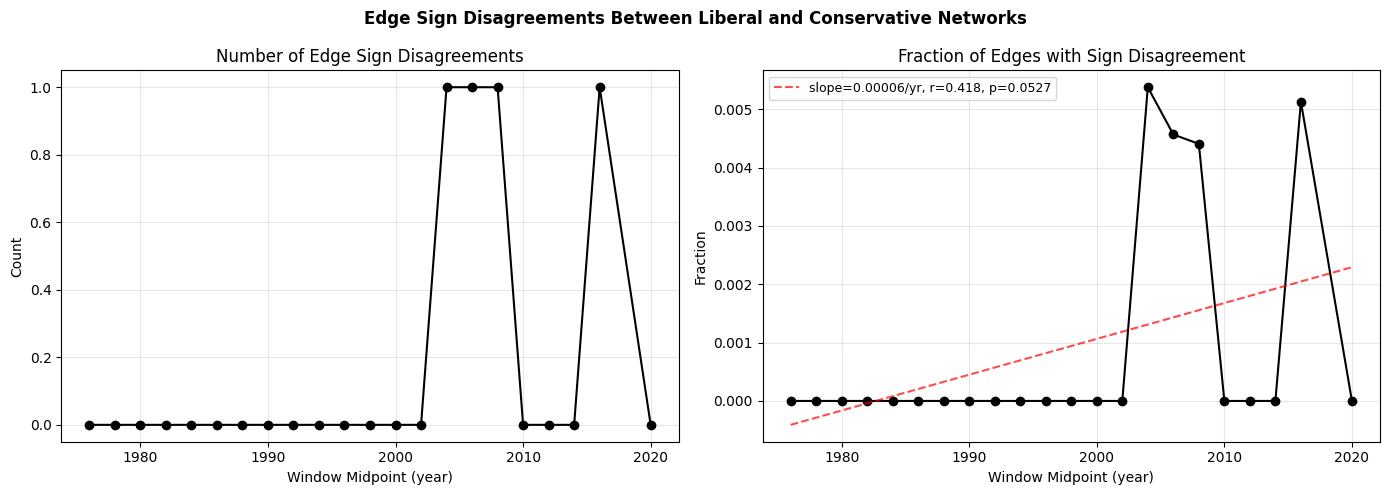


Sign-flipped edges in latest window (2018-2022): 0
Var 1                     Var 2                          Lib      Con
--------------------------------------------------------------------


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(df_signs['mid_year'], df_signs['n_sign_disagree'], 'ko-')
ax.set_ylabel('Count')
ax.set_title('Number of Edge Sign Disagreements')
ax.set_xlabel('Window Midpoint (year)')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(df_signs['mid_year'], df_signs['frac_sign_disagree'], 'ko-')
ax.set_ylabel('Fraction')
ax.set_title('Fraction of Edges with Sign Disagreement')
ax.set_xlabel('Window Midpoint (year)')
ax.grid(True, alpha=0.3)
x = df_signs['mid_year'].values
ax.plot(x, intercept_s + slope_s * x, 'r--', alpha=0.7,
        label=f'slope={slope_s:.5f}/yr, r={r_s:.3f}, p={p_s:.4f}')
ax.legend(fontsize=9)

plt.suptitle('Edge Sign Disagreements Between Liberal and Conservative Networks', fontweight='bold')
plt.tight_layout()
plt.show()

# Identify specific edges that flip sign in the latest window
w_last = window_data[-1]
lib_last = w_last['corr_lib'].values
con_last = w_last['corr_con'].values
vars_last = w_last['common_vars']
n_last = len(vars_last)
triu_last = np.triu_indices(n_last, k=1)

flipped = []
for idx in range(len(triu_last[0])):
    i, j = triu_last[0][idx], triu_last[1][idx]
    lv, cv = lib_last[i, j], con_last[i, j]
    if lv != 0 and cv != 0 and np.sign(lv) != np.sign(cv):
        flipped.append((vars_last[i], vars_last[j], lv, cv))

flipped.sort(key=lambda x: abs(x[2] - x[3]), reverse=True)
print(f"\nSign-flipped edges in latest window ({w_last['start']}-{w_last['end']}): {len(flipped)}")
print(f"{'Var 1':25s} {'Var 2':25s} {'Lib':>8s} {'Con':>8s}")
print('-' * 68)
for v1, v2, lv, cv in flipped[:20]:
    print(f"{v1:25s} {v2:25s} {lv:+8.4f} {cv:+8.4f}")

## 4.2 Dimensionality Divergence

Are the two networks becoming structurally different in their dimensionality?

- **PC1 variance explained**: How much of the belief space is captured by one dimension?
- **Participation ratio**: `PR = (sum(lambda))^2 / sum(lambda^2)` — effective number of dimensions

In [6]:
dim_data = []

for w in window_data:
    for label, corr_mat in [('lib', w['corr_lib']), ('con', w['corr_con'])]:
        mat = corr_mat.values.copy()
        np.fill_diagonal(mat, 1.0)

        eigenvalues = np.linalg.eigvalsh(mat)
        eigenvalues = np.sort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[eigenvalues > 0]

        total_var = eigenvalues.sum()
        pc1_var = eigenvalues[0] / total_var if total_var > 0 else 0
        pr = (eigenvalues.sum())**2 / (eigenvalues**2).sum()

        dim_data.append({
            'mid_year': w['mid_year'],
            'group': label,
            'pc1_var': pc1_var,
            'participation_ratio': pr,
            'n_vars': len(eigenvalues),
        })

df_dim = pd.DataFrame(dim_data)
df_dim_lib = df_dim[df_dim['group'] == 'lib'].reset_index(drop=True)
df_dim_con = df_dim[df_dim['group'] == 'con'].reset_index(drop=True)

print("=== Dimensionality Metrics ===")
print(f"{'Year':>6s} {'PC1(lib)':>9s} {'PC1(con)':>9s} {'PR(lib)':>8s} {'PR(con)':>8s}")
for _, rl in df_dim_lib.iterrows():
    rc = df_dim_con[df_dim_con['mid_year'] == rl['mid_year']].iloc[0]
    print(f"{rl['mid_year']:6.0f} {rl['pc1_var']:9.4f} {rc['pc1_var']:9.4f} "
          f"{rl['participation_ratio']:8.2f} {rc['participation_ratio']:8.2f}")

=== Dimensionality Metrics ===
  Year  PC1(lib)  PC1(con)  PR(lib)  PR(con)
  1976    0.0236    0.0232    75.02    74.80
  1978    0.0235    0.0231    74.98    74.64
  1980    0.0230    0.0225    76.71    76.35
  1982    0.0217    0.0213    81.37    80.95
  1984    0.0193    0.0190    91.67    91.52
  1986    0.0180    0.0177    98.54    98.39
  1988    0.0177    0.0174    99.05    99.32
  1990    0.0178    0.0176    98.06    97.97
  1992    0.0174    0.0173   100.24    99.46
  1994    0.0174    0.0172   100.43    99.49
  1996    0.0170    0.0170   102.45   101.25
  1998    0.0187    0.0186    92.94    91.88
  2000    0.0183    0.0183    94.93    94.45
  2002    0.0162    0.0163   107.57   106.64
  2004    0.0165    0.0164   106.56   105.97
  2006    0.0163    0.0162   108.21   107.44
  2008    0.0160    0.0159   110.12   109.26
  2010    0.0159    0.0157   111.28   110.52
  2012    0.0176    0.0173   100.49    99.89
  2014    0.0164    0.0161   108.44   107.33
  2016    0.0178    0.01

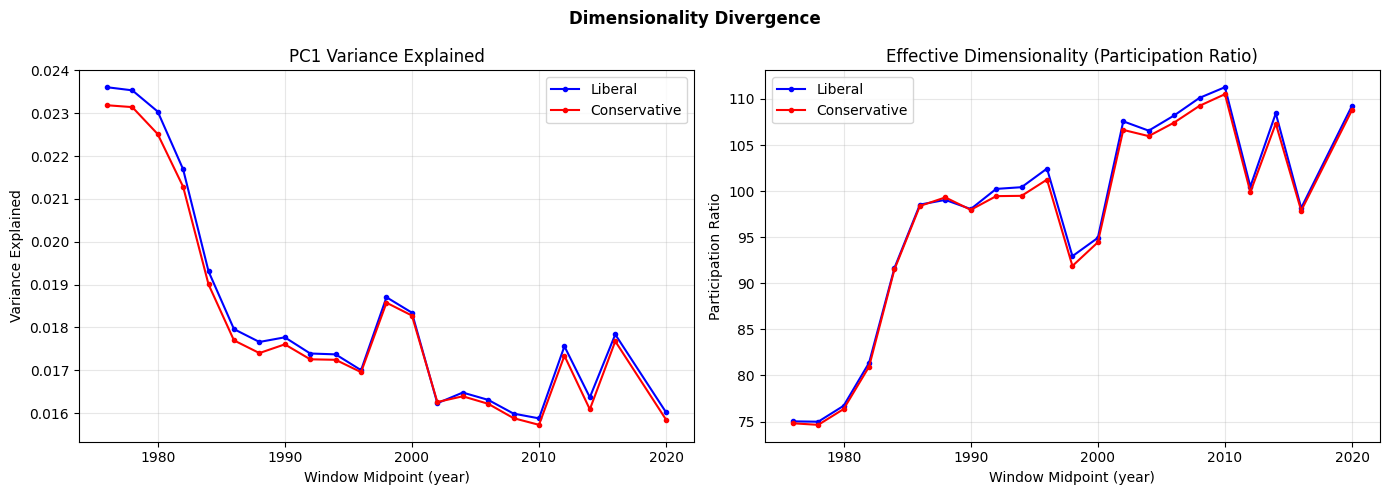

=== Trends ===
PC1 var explained (lib): slope=-0.000148/yr, r=-0.789, p=0.0000
PC1 var explained (con): slope=-0.000141/yr, r=-0.791, p=0.0000
Participation ratio (lib): slope=0.701074/yr, r=0.809, p=0.0000
Participation ratio (con): slope=0.687932/yr, r=0.805, p=0.0000


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(df_dim_lib['mid_year'], df_dim_lib['pc1_var'], 'b.-', label='Liberal')
ax.plot(df_dim_con['mid_year'], df_dim_con['pc1_var'], 'r.-', label='Conservative')
ax.set_ylabel('Variance Explained')
ax.set_title('PC1 Variance Explained')
ax.set_xlabel('Window Midpoint (year)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(df_dim_lib['mid_year'], df_dim_lib['participation_ratio'], 'b.-', label='Liberal')
ax.plot(df_dim_con['mid_year'], df_dim_con['participation_ratio'], 'r.-', label='Conservative')
ax.set_ylabel('Participation Ratio')
ax.set_title('Effective Dimensionality (Participation Ratio)')
ax.set_xlabel('Window Midpoint (year)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Dimensionality Divergence', fontweight='bold')
plt.tight_layout()
plt.show()

print("=== Trends ===")
for metric, label in [('pc1_var', 'PC1 var explained'), ('participation_ratio', 'Participation ratio')]:
    for group, df_g in [('lib', df_dim_lib), ('con', df_dim_con)]:
        s, i, r, p, se = linregress(df_g['mid_year'], df_g[metric])
        print(f"{label} ({group}): slope={s:.6f}/yr, r={r:.3f}, p={p:.4f}")

## 4.3 Edge-Level Divergence Drivers

Which specific edges are driving the overall divergence?

For each edge (i,j), compute the temporal slope of |lib_weight - con_weight|.
Steepest positive slopes = fastest diverging. Steepest negative = converging.

In [8]:
# Build time series of |lib - con| for each edge across windows
edge_timeseries = {}

for w in window_data:
    vars_w = w['common_vars']
    lib_mat = w['corr_lib']
    con_mat = w['corr_con']

    for i_idx, v1 in enumerate(vars_w):
        for j_idx in range(i_idx + 1, len(vars_w)):
            v2 = vars_w[j_idx]
            edge = (v1, v2)
            if edge not in edge_timeseries:
                edge_timeseries[edge] = {}
            diff = abs(lib_mat.iloc[i_idx, j_idx] - con_mat.iloc[i_idx, j_idx])
            edge_timeseries[edge][w['mid_year']] = diff

# Compute temporal slope for each edge (>= 5 data points)
edge_slopes = []
for edge, ts in edge_timeseries.items():
    if len(ts) < 5:
        continue
    years = np.array(sorted(ts.keys()))
    diffs = np.array([ts[y] for y in years])
    slope, intercept, r, p, se = linregress(years, diffs)
    edge_slopes.append({
        'var1': edge[0], 'var2': edge[1],
        'slope': slope, 'r': r, 'p': p,
        'mean_diff': diffs.mean(), 'n_windows': len(ts),
    })

df_edges = pd.DataFrame(edge_slopes).sort_values('slope', ascending=False)
print(f"Total edges tracked: {len(df_edges)}")

print(f"\n=== Top 20 Fastest-DIVERGING Edges ===")
print(df_edges.head(20)[['var1', 'var2', 'slope', 'r', 'p', 'mean_diff']].to_string(index=False))

print(f"\n=== Top 20 Fastest-CONVERGING Edges ===")
print(df_edges.tail(20).sort_values('slope')[['var1', 'var2', 'slope', 'r', 'p', 'mean_diff']].to_string(index=False))

Total edges tracked: 6843

=== Top 20 Fastest-DIVERGING Edges ===
           var1             var2    slope        r            p  mean_diff
        LIBMSLM           LIBRAC 0.003856 0.622558 1.353951e-01   0.059164
         NATSCI          NATSPAC 0.003811 0.687616 1.311339e-01   0.031218
        RACDIF2          RACDIF4 0.003302 0.849947 7.981277e-06   0.064683
        LIBMSLM           PRAYER 0.003244 0.891459 7.026023e-03   0.038013
         COURTS         WRKWAYUP 0.003113 0.728930 3.100370e-03   0.046311
        HELPNOT          SPKMSLM 0.002680 0.705656 7.646009e-02   0.006919
    DIDVOTELAST          PARTYID 0.002516 0.853997 4.287314e-07   0.026707
         CONFED         CONLEGIS 0.002511 0.477405 2.464967e-02   0.073111
          FEFAM         POLMURDR 0.002463 0.801751 6.305436e-05   0.023117
        HELPOTH         THNKSELF 0.002424 0.724203 1.010947e-03   0.067385
         CONSCI           NATSCI 0.002389 0.658714 5.368357e-02   0.019120
        NATROAD           NATSCI 0

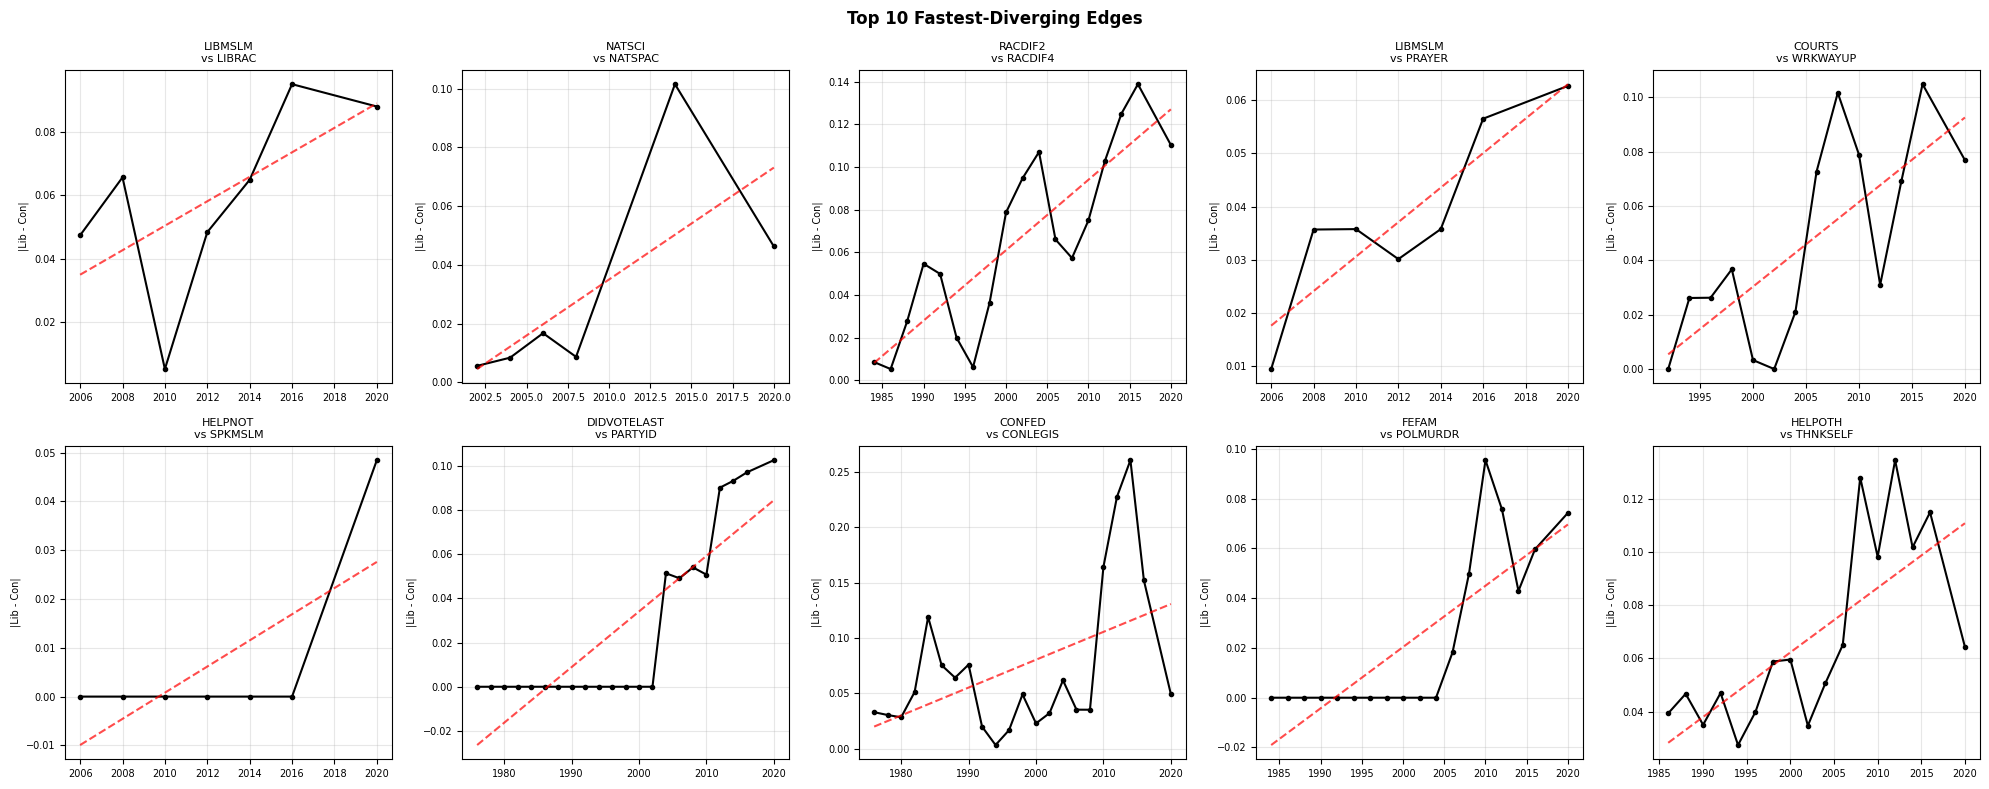


Edges with positive slope (diverging): 936
Edges with negative slope (converging): 775
Significantly diverging (p<0.05): 208
Significantly converging (p<0.05): 127


In [9]:
# Plot timeseries for top 10 diverging edges
top_10 = df_edges.head(10)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes_flat = axes.flatten()

for idx, (_, row) in enumerate(top_10.iterrows()):
    edge = (row['var1'], row['var2'])
    ts = edge_timeseries[edge]
    years = np.array(sorted(ts.keys()))
    diffs = np.array([ts[y] for y in years])

    ax = axes_flat[idx]
    ax.plot(years, diffs, 'ko-', markersize=3)
    s, i_val, r, p, se = linregress(years, diffs)
    ax.plot(years, i_val + s * years, 'r--', alpha=0.7)
    ax.set_title(f"{row['var1']}\nvs {row['var2']}", fontsize=8)
    ax.set_ylabel('|Lib - Con|', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Top 10 Fastest-Diverging Edges', fontweight='bold')
plt.tight_layout()
plt.show()

# Summary stats
n_diverging = (df_edges['slope'] > 0).sum()
n_converging = (df_edges['slope'] < 0).sum()
n_sig_div = ((df_edges['slope'] > 0) & (df_edges['p'] < 0.05)).sum()
n_sig_conv = ((df_edges['slope'] < 0) & (df_edges['p'] < 0.05)).sum()
print(f"\nEdges with positive slope (diverging): {n_diverging}")
print(f"Edges with negative slope (converging): {n_converging}")
print(f"Significantly diverging (p<0.05): {n_sig_div}")
print(f"Significantly converging (p<0.05): {n_sig_conv}")

## 4.4 Domain Decomposition of Divergence

Which belief domains contribute most to the overall divergence?

Using the 10 communities from sound_01 as fixed domain labels, decompose
total d² into within-domain and between-domain contributions.

In [10]:
# Fixed domain labels from sound_01 community detection (reference network 2000-2010)
DOMAIN_LABELS = {
    'Political': [
        'POLVIEWS', 'PARTYID', 'PRESLAST_DEMREP', 'WOULDVOTELAST_DEMREP',
        'PRESLAST_NONCONFORM', 'WOULDVOTELAST_NONCONFORM',
        'EQWLTH', 'HELPBLK', 'HELPNOT', 'HELPPOOR',
        'AFFRMACT', 'WRKWAYUP', 'RACDIF1', 'RACDIF2', 'RACDIF3', 'RACDIF4',
        'CAPPUN', 'COURTS', 'GETAHEAD', 'DIDVOTELAST', 'GUNLAW',
        'NATFARE', 'NATFAREY', 'NATRACE', 'NATRACEY',
    ],
    'Civil liberties': [
        'SPKATH', 'SPKCOM', 'SPKHOMO', 'SPKMIL', 'SPKMSLM', 'SPKRAC',
        'COLATH', 'COLCOM', 'COLHOMO', 'COLMIL', 'COLMSLM', 'COLRAC',
        'LIBATH', 'LIBCOM', 'LIBHOMO', 'LIBMIL', 'LIBMSLM', 'LIBRAC',
    ],
    'Morality/family': [
        'HOMOSEX', 'PREMARSX', 'TEENSEX', 'XMARSEX', 'GRASS', 'PORNLAW',
        'PRAYER', 'SPANKING', 'FEFAM', 'FEPOL', 'FEPRESCH', 'FECHLD',
        'DIVLAW', 'SEXEDUC', 'MARHOMO',
    ],
    'Institutions': [
        'CONARMY', 'CONBUS', 'CONEDUC', 'CONFED', 'CONFINAN',
        'CONJUDGE', 'CONLABOR', 'CONLEGIS', 'CONMEDIC', 'CONPRESS',
        'CONSCI', 'CONTV',
    ],
    'Spending': [
        'NATEDUC', 'NATEDUCY', 'NATENRGY', 'NATENVIR', 'NATENVIY',
        'NATHEAL', 'NATHEALY', 'NATSCI', 'NATPARK', 'NATMASS',
        'NATROAD', 'NATSPAC', 'NATSPACY', 'NATSOC',
        'NATAID', 'NATAIDY', 'NATARMS', 'NATARMSY',
        'NATCITY', 'NATCITYY', 'NATCRIME', 'NATCRIMY',
        'NATDRUG', 'NATDRUGY', 'NATCHLD',
    ],
    'Abortion': [
        'ABANY', 'ABDEFECT', 'ABHLTH', 'ABNOMORE', 'ABPOOR', 'ABRAPE', 'ABSINGLE',
        'LETDIE1', 'SUICIDE1', 'SUICIDE2',
    ],
    'Child-rearing': [
        'OBEY', 'THNKSELF', 'WORKHARD', 'HELPOTH', 'POPULAR',
    ],
    'Police': [
        'POLABUSE', 'POLATTAK', 'POLESCAP', 'POLHITOK', 'POLMURDR',
    ],
    'Religion': [
        'CONCLERG', 'POSTLIFE',
        'RELIG_Protestant', 'RELIG_Catholic', 'RELIG_None',
        'RELIG_Jewish', 'RELIG_Other', 'RELIG_Buddhism', 'RELIG_Hinduism',
        'RELIG_Other_eastern_religions', 'RELIG_Muslim',
        'RELIG_Orthodox_christian', 'RELIG_Christian',
        'RELIG_Inter_nondenominational',
    ],
    'Social trust': [
        'FAIR', 'HELPFUL', 'TRUST',
    ],
}

# Build reverse mapping
var_to_domain = {}
for domain, vars_list in DOMAIN_LABELS.items():
    for v in vars_list:
        var_to_domain[v] = domain

# Check coverage
all_network_vars = set()
for w in window_data:
    all_network_vars.update(w['common_vars'])
assigned = all_network_vars & set(var_to_domain.keys())
unassigned = all_network_vars - set(var_to_domain.keys())
print(f"Variables in networks: {len(all_network_vars)}")
print(f"Assigned to domains: {len(assigned)}")
print(f"Unassigned: {len(unassigned)}")
if unassigned:
    print(f"  {sorted(unassigned)}")

Variables in networks: 131
Assigned to domains: 131
Unassigned: 0


In [11]:
# Decompose total d² into domain-pair contributions
domain_names = sorted(DOMAIN_LABELS.keys())
n_domains = len(domain_names)

domain_pair_keys = []
for i in range(n_domains):
    for j in range(i, n_domains):
        domain_pair_keys.append((domain_names[i], domain_names[j]))

decomp_data = []

for w in window_data:
    vars_w = w['common_vars']
    lib_mat = w['corr_lib'].values
    con_mat = w['corr_con'].values
    n = len(vars_w)

    var_domains = [var_to_domain.get(v, None) for v in vars_w]

    pair_contributions = {k: 0.0 for k in domain_pair_keys}
    total_d2 = 0.0
    unassigned_d2 = 0.0

    for i_idx in range(n):
        for j_idx in range(i_idx + 1, n):
            d2_ij = (lib_mat[i_idx, j_idx] - con_mat[i_idx, j_idx]) ** 2
            total_d2 += d2_ij

            d1 = var_domains[i_idx]
            d2 = var_domains[j_idx]

            if d1 is None or d2 is None:
                unassigned_d2 += d2_ij
                continue

            pair = tuple(sorted([d1, d2]))
            if pair in pair_contributions:
                pair_contributions[pair] += d2_ij

    row = {'mid_year': w['mid_year'], 'total_d2': total_d2, 'unassigned_d2': unassigned_d2}
    for pair, val in pair_contributions.items():
        label = f"{pair[0]} x {pair[1]}" if pair[0] != pair[1] else f"{pair[0]} (within)"
        row[label] = val
    decomp_data.append(row)

df_decomp = pd.DataFrame(decomp_data)

# Verify sums
contrib_cols = [c for c in df_decomp.columns if c not in ['mid_year', 'total_d2']]
df_decomp['sum_check'] = df_decomp[contrib_cols].sum(axis=1)
print("Verification: domain contributions sum = total d²")
print(f"  Max absolute error: {(df_decomp['sum_check'] - df_decomp['total_d2']).abs().max():.2e}")

# Show top contributing domain pairs (averaged over time)
analysis_cols = [c for c in contrib_cols if c != 'unassigned_d2']
mean_contribs = df_decomp[analysis_cols].mean().sort_values(ascending=False)
total_mean = df_decomp['total_d2'].mean()

print(f"\n=== Average d² Contribution by Domain Pair ===")
for label, val in mean_contribs.head(20).items():
    print(f"  {label:45s} {val:.4f}  ({val/total_mean*100:5.1f}%)")

# Within vs between totals
within_cols = [c for c in analysis_cols if '(within)' in c]
between_cols = [c for c in analysis_cols if '(within)' not in c]
within_mean = df_decomp[within_cols].sum(axis=1).mean()
between_mean = df_decomp[between_cols].sum(axis=1).mean()
print(f"\nWithin-domain d²:  {within_mean:.4f} ({within_mean/total_mean*100:.1f}%)")
print(f"Between-domain d²: {between_mean:.4f} ({between_mean/total_mean*100:.1f}%)")

Verification: domain contributions sum = total d²
  Max absolute error: 2.00e-15

=== Average d² Contribution by Domain Pair ===
  Political (within)                            0.1957  ( 21.0%)
  Civil liberties (within)                      0.1063  ( 11.4%)
  Morality/family (within)                      0.0854  (  9.2%)
  Institutions (within)                         0.0769  (  8.3%)
  Religion (within)                             0.0736  (  7.9%)
  Abortion (within)                             0.0525  (  5.6%)
  Spending (within)                             0.0524  (  5.6%)
  Civil liberties x Morality/family             0.0413  (  4.4%)
  Abortion x Morality/family                    0.0394  (  4.2%)
  Political x Spending                          0.0297  (  3.2%)
  Child-rearing (within)                        0.0196  (  2.1%)
  Morality/family x Religion                    0.0123  (  1.3%)
  Child-rearing x Morality/family               0.0119  (  1.3%)
  Morality/family x Politi

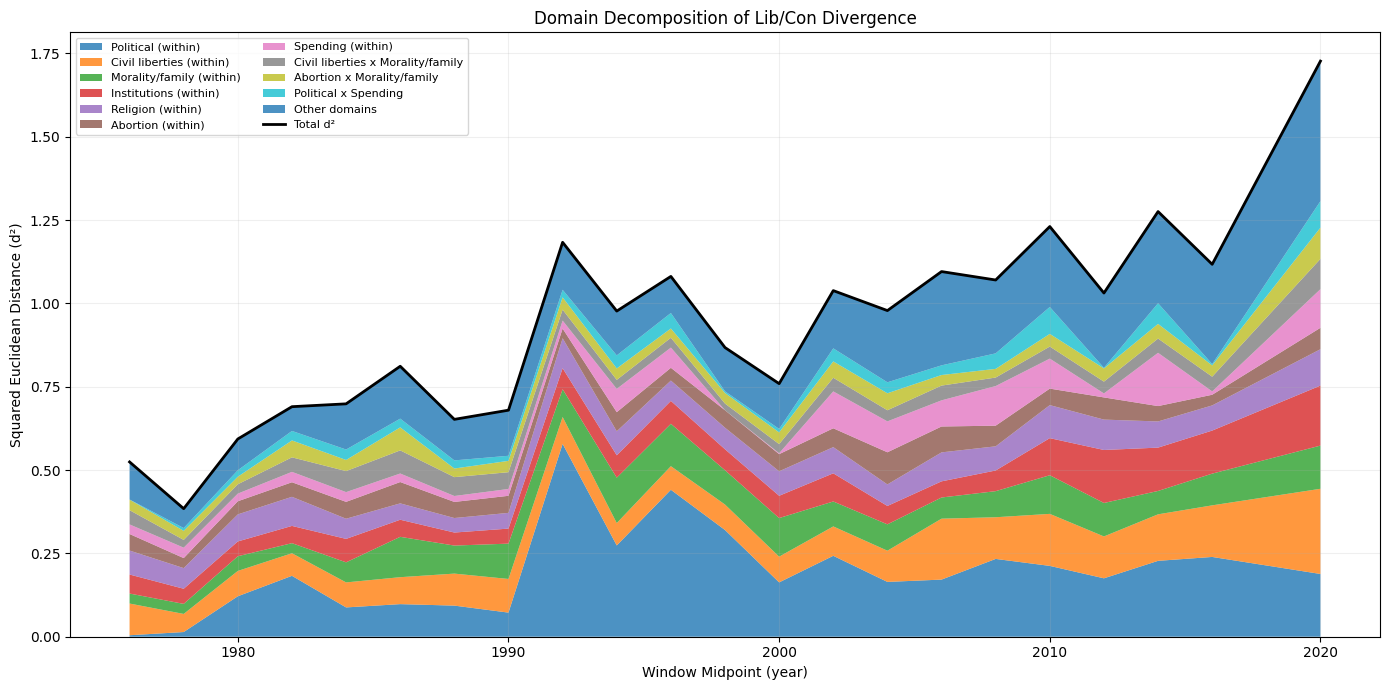

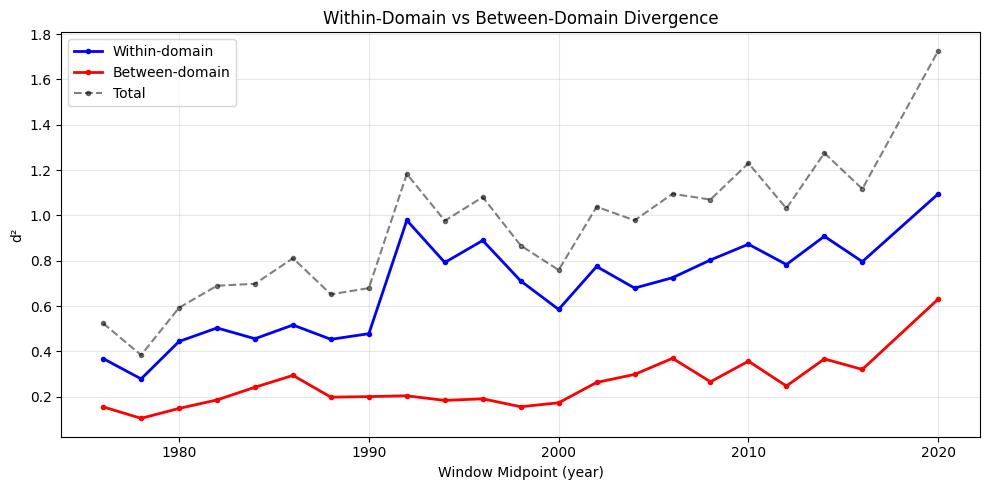

=== Trends ===
Within-domain d² trend: slope=0.01340/yr, r=0.815, p=0.0000
Between-domain d² trend: slope=0.00637/yr, r=0.741, p=0.0001
Total d² trend: slope=0.01977/yr, r=0.861, p=0.0000

Within-domain share trend: slope=-0.000269/yr, r=-0.061, p=0.7858


In [12]:
# Stacked area chart of domain-pair contributions
top_n_pairs = 10
top_labels = mean_contribs.head(top_n_pairs).index.tolist()
other_analysis = [c for c in analysis_cols if c not in top_labels]

plot_df = df_decomp[['mid_year'] + top_labels].copy()
plot_df['Other domains'] = df_decomp[other_analysis + ['unassigned_d2']].sum(axis=1)

fig, ax = plt.subplots(figsize=(14, 7))
cols_to_stack = top_labels + ['Other domains']
ax.stackplot(plot_df['mid_year'], *[plot_df[c] for c in cols_to_stack],
             labels=cols_to_stack, alpha=0.8)
ax.plot(df_decomp['mid_year'], df_decomp['total_d2'], 'k-', linewidth=2, label='Total d²')
ax.set_xlabel('Window Midpoint (year)')
ax.set_ylabel('Squared Euclidean Distance (d²)')
ax.set_title('Domain Decomposition of Lib/Con Divergence')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Within vs between over time
fig, ax = plt.subplots(figsize=(10, 5))
within_ts = df_decomp[within_cols].sum(axis=1)
between_ts = df_decomp[between_cols].sum(axis=1)
ax.plot(df_decomp['mid_year'], within_ts, 'b.-', label='Within-domain', linewidth=2)
ax.plot(df_decomp['mid_year'], between_ts, 'r.-', label='Between-domain', linewidth=2)
ax.plot(df_decomp['mid_year'], df_decomp['total_d2'], 'k.--', label='Total', alpha=0.5)
ax.set_xlabel('Window Midpoint (year)')
ax.set_ylabel('d²')
ax.set_title('Within-Domain vs Between-Domain Divergence')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Trends
print("=== Trends ===")
for series, label in [(within_ts, 'Within-domain'), (between_ts, 'Between-domain'),
                       (df_decomp['total_d2'], 'Total')]:
    s, i, r, p, se = linregress(df_decomp['mid_year'], series)
    print(f"{label} d² trend: slope={s:.5f}/yr, r={r:.3f}, p={p:.4f}")

# Within-domain share over time
within_share = within_ts / df_decomp['total_d2']
s_share, i_share, r_share, p_share, _ = linregress(df_decomp['mid_year'], within_share)
print(f"\nWithin-domain share trend: slope={s_share:.6f}/yr, r={r_share:.3f}, p={p_share:.4f}")

## 4.5 Modularity Divergence

Are the two networks becoming differently modular?

If conservatives are becoming more modular while liberals are becoming less (or vice versa),
that suggests different organizational strategies for beliefs.

In [13]:
mod_data = []

for w in window_data:
    for label, corr_mat in [('lib', w['corr_lib']), ('con', w['corr_con'])]:
        mat = corr_mat.copy()
        np.fill_diagonal(mat.values, 0)
        G = nx.from_pandas_adjacency(mat.abs())
        G.remove_edges_from([(u, v) for u, v, d in G.edges(data=True) if d['weight'] == 0])

        if G.number_of_edges() == 0:
            continue

        comms = nx.community.louvain_communities(G, weight='weight', seed=42)
        Q = nx.community.modularity(G, comms, weight='weight')
        n_comms = sum(1 for c in comms if len(c) >= 3)

        mod_data.append({
            'mid_year': w['mid_year'],
            'group': label,
            'modularity': Q,
            'n_communities': n_comms,
        })

df_mod = pd.DataFrame(mod_data)
df_mod_lib = df_mod[df_mod['group'] == 'lib'].reset_index(drop=True)
df_mod_con = df_mod[df_mod['group'] == 'con'].reset_index(drop=True)

print("=== Modularity Over Time ===")
print(f"{'Year':>6s} {'Q(lib)':>8s} {'Q(con)':>8s} {'#C(lib)':>8s} {'#C(con)':>8s}")
for _, rl in df_mod_lib.iterrows():
    rc = df_mod_con[df_mod_con['mid_year'] == rl['mid_year']].iloc[0]
    print(f"{rl['mid_year']:6.0f} {rl['modularity']:8.4f} {rc['modularity']:8.4f} "
          f"{rl['n_communities']:8.0f} {rc['n_communities']:8.0f}")

=== Modularity Over Time ===
  Year   Q(lib)   Q(con)  #C(lib)  #C(con)
  1976   0.6130   0.6866        8        8
  1978   0.6408   0.7042        9        9
  1980   0.6332   0.7128        8        9
  1982   0.6537   0.7221        8        8
  1984   0.6484   0.7091        9        9
  1986   0.6570   0.6952        8       10
  1988   0.6646   0.7325       10        9
  1990   0.6751   0.7406       10       10
  1992   0.6856   0.7460       10       10
  1994   0.7038   0.7406       10       10
  1996   0.7153   0.7505       12        9
  1998   0.6973   0.7565       10       10
  2000   0.6726   0.7433        9        9
  2002   0.6701   0.7292        9       11
  2004   0.6723   0.7432        9        8
  2006   0.6429   0.7067       10        9
  2008   0.6502   0.7306        9        9
  2010   0.6417   0.7093       10        8
  2012   0.6209   0.7133        9        8
  2014   0.6150   0.7232        9        9
  2016   0.6283   0.7357        8        9
  2020   0.6111   0.7193 

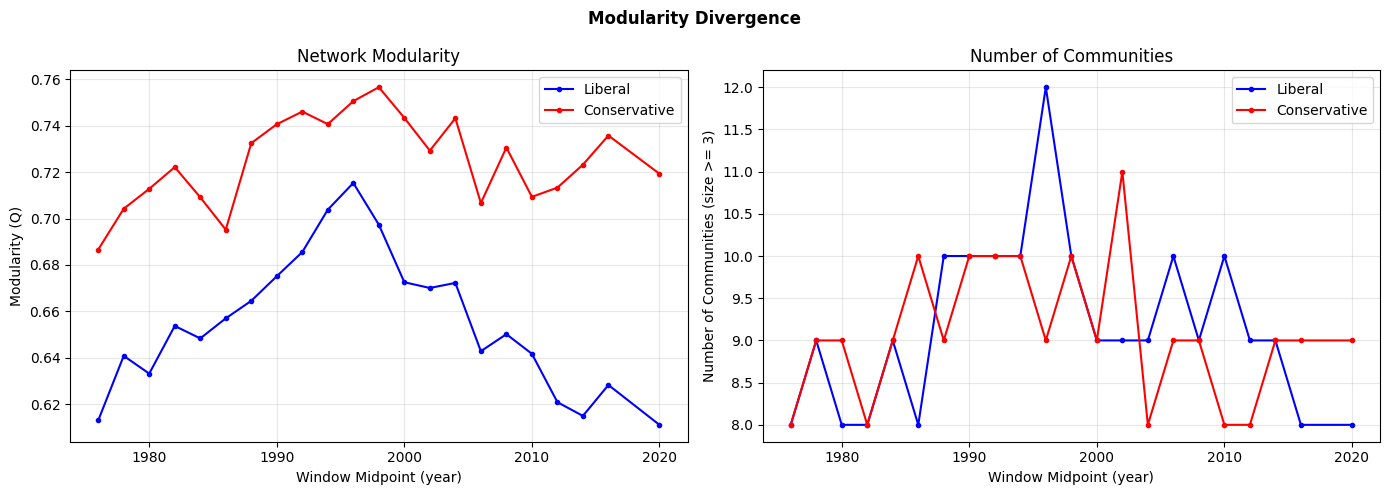

=== Trends ===
modularity (lib): slope=-0.00048/yr, r=-0.213, p=0.3420
modularity (con): slope=0.00039/yr, r=0.275, p=0.2163
n_communities (lib): slope=0.00486/yr, r=0.063, p=0.7790
n_communities (con): slope=-0.00391/yr, r=-0.063, p=0.7795


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(df_mod_lib['mid_year'], df_mod_lib['modularity'], 'b.-', label='Liberal')
ax.plot(df_mod_con['mid_year'], df_mod_con['modularity'], 'r.-', label='Conservative')
ax.set_ylabel('Modularity (Q)')
ax.set_title('Network Modularity')
ax.set_xlabel('Window Midpoint (year)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(df_mod_lib['mid_year'], df_mod_lib['n_communities'], 'b.-', label='Liberal')
ax.plot(df_mod_con['mid_year'], df_mod_con['n_communities'], 'r.-', label='Conservative')
ax.set_ylabel('Number of Communities (size >= 3)')
ax.set_title('Number of Communities')
ax.set_xlabel('Window Midpoint (year)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Modularity Divergence', fontweight='bold')
plt.tight_layout()
plt.show()

print("=== Trends ===")
for metric in ['modularity', 'n_communities']:
    for group, df_g in [('lib', df_mod_lib), ('con', df_mod_con)]:
        s, i, r, p, se = linregress(df_g['mid_year'], df_g[metric])
        print(f"{metric} ({group}): slope={s:.5f}/yr, r={r:.3f}, p={p:.4f}")

## 4.6 Centrality Divergence

Are the two groups increasingly disagreeing on which beliefs are "central"?

Track the Spearman rank correlation of degree centrality rankings over time.
A declining correlation means the groups increasingly disagree on which beliefs
are structurally important.

In [15]:
cent_rank_corr = []
cent_changes = {}

for w in window_data:
    vars_w = w['common_vars']
    lib_mat = w['corr_lib'].copy()
    con_mat = w['corr_con'].copy()

    np.fill_diagonal(lib_mat.values, 0)
    np.fill_diagonal(con_mat.values, 0)

    G_lib = nx.from_pandas_adjacency(lib_mat.abs())
    G_con = nx.from_pandas_adjacency(con_mat.abs())
    G_lib.remove_edges_from([(u, v) for u, v, d in G_lib.edges(data=True) if d['weight'] == 0])
    G_con.remove_edges_from([(u, v) for u, v, d in G_con.edges(data=True) if d['weight'] == 0])

    deg_lib = nx.degree_centrality(G_lib)
    deg_con = nx.degree_centrality(G_con)

    common_nodes = sorted(set(deg_lib.keys()) & set(deg_con.keys()))
    lib_cents = [deg_lib[n] for n in common_nodes]
    con_cents = [deg_con[n] for n in common_nodes]

    rho, p_val = spearmanr(lib_cents, con_cents)

    cent_rank_corr.append({
        'mid_year': w['mid_year'],
        'spearman_rho': rho,
        'p_value': p_val,
    })

    lib_ranked = pd.Series(lib_cents, index=common_nodes).rank(ascending=False)
    con_ranked = pd.Series(con_cents, index=common_nodes).rank(ascending=False)

    for v in common_nodes:
        if v not in cent_changes:
            cent_changes[v] = {}
        cent_changes[v][w['mid_year']] = lib_ranked[v] - con_ranked[v]

df_cent = pd.DataFrame(cent_rank_corr)
print("=== Centrality Rank Correlation Over Time ===")
print(df_cent.to_string(index=False))

s_cent, i_cent, r_cent, p_cent, _ = linregress(df_cent['mid_year'], df_cent['spearman_rho'])
print(f"\nTrend: slope={s_cent:.5f}/yr, r={r_cent:.3f}, p={p_cent:.4f}")

=== Centrality Rank Correlation Over Time ===
 mid_year  spearman_rho      p_value
   1976.0      0.793157 1.791063e-18
   1978.0      0.839296 2.425581e-22
   1980.0      0.790294 1.070279e-18
   1982.0      0.712244 1.031992e-14
   1984.0      0.677901 1.760825e-14
   1986.0      0.803789 5.700794e-25
   1988.0      0.783806 3.002884e-23
   1990.0      0.744043 9.559254e-20
   1992.0      0.696041 8.643096e-17
   1994.0      0.617371 1.418265e-12
   1996.0      0.603404 3.805161e-12
   1998.0      0.619176 8.408131e-12
   2000.0      0.715456 4.232473e-17
   2002.0      0.555610 1.395338e-10
   2004.0      0.662858 1.268179e-15
   2006.0      0.667820 3.582933e-16
   2008.0      0.620254 8.794368e-14
   2010.0      0.546178 1.583314e-10
   2012.0      0.670619 2.749526e-15
   2014.0      0.476981 7.077108e-08
   2016.0      0.619994 1.757308e-12
   2020.0      0.583119 5.256489e-12

Trend: slope=-0.00563/yr, r=-0.784, p=0.0000


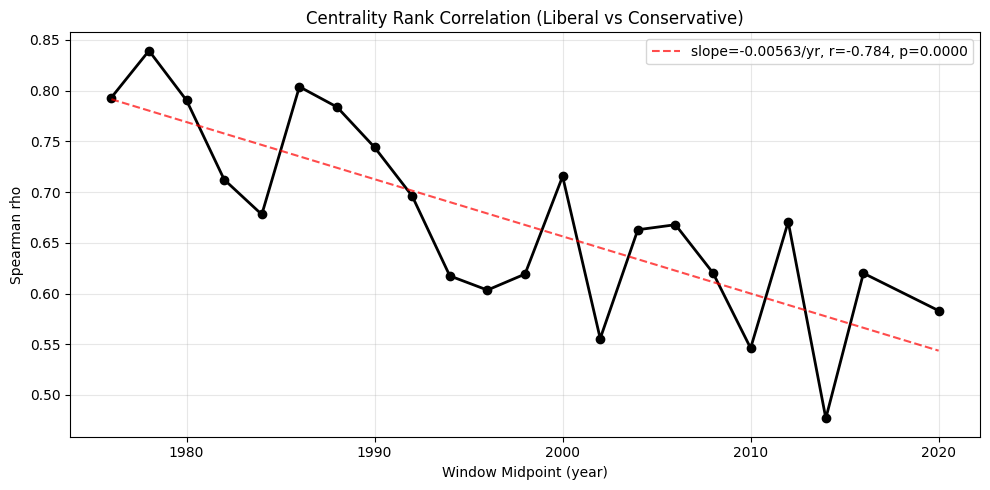


=== Variables with Fastest-Growing Centrality Rank Disagreement ===
            variable    slope        r        p  mean_rank_diff  last_rank_diff
            WRKWAYUP 1.535503 0.891202 0.000019      -41.821429           -68.0
            POLMURDR 1.494565 0.821494 0.000003      -22.590909           -51.0
            AFFRMACT 1.303550 0.485677 0.078302       37.321429            12.5
             NATCITY 1.195642 0.708888 0.001443       34.676471            73.5
            CONPRESS 1.170933 0.806654 0.000006       23.204545            39.0
              PRAYER 1.170851 0.592641 0.005894      -59.650000           -78.5
               FEFAM 1.141143 0.817029 0.000035      -14.333333           -33.5
              NATAID 1.098912 0.767623 0.000321        4.764706            73.5
             RACDIF4 1.071373 0.695404 0.001355      -57.138889           -63.5
WOULDVOTELAST_DEMREP 1.012320 0.691943 0.002979       21.062500            33.0
            NATENVIR 0.977777 0.517324 0.033444    

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_cent['mid_year'], df_cent['spearman_rho'], 'ko-', linewidth=2)
x = df_cent['mid_year'].values
ax.plot(x, i_cent + s_cent * x, 'r--', alpha=0.7,
        label=f'slope={s_cent:.5f}/yr, r={r_cent:.3f}, p={p_cent:.4f}')
ax.set_xlabel('Window Midpoint (year)')
ax.set_ylabel('Spearman rho')
ax.set_title('Centrality Rank Correlation (Liberal vs Conservative)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Variables with largest centrality rank divergence over time
cent_slopes = []
for v, ts in cent_changes.items():
    if len(ts) < 5:
        continue
    years = np.array(sorted(ts.keys()))
    diffs = np.array([ts[y] for y in years])
    slope_v, _, r_v, p_v, _ = linregress(years, np.abs(diffs))
    cent_slopes.append({
        'variable': v, 'slope': slope_v, 'r': r_v, 'p': p_v,
        'mean_rank_diff': np.mean(diffs),
        'last_rank_diff': diffs[-1],
    })

df_cent_slopes = pd.DataFrame(cent_slopes).sort_values('slope', ascending=False)

print("\n=== Variables with Fastest-Growing Centrality Rank Disagreement ===")
print(df_cent_slopes.head(15).to_string(index=False))

print("\n=== Variables with Largest Final Centrality Rank Difference ===")
df_final_diff = df_cent_slopes.sort_values('last_rank_diff', key=abs, ascending=False)
print(df_final_diff.head(15)[['variable', 'mean_rank_diff', 'last_rank_diff']].to_string(index=False))

## Summary

See `analyses/2026-02_sound-divergence-anatomy.md` for the full writeup.